# gleis404 — demo: how punctual is Dortmund transit, really?

`gleis404` collects realtime departure data from the free
[Transitous](https://transitous.org/) API every five minutes, stores
delay history in SQLite, and turns it into punctuality statistics and
figures.

**Watchlist:** Dortmund Hbf, An der Palmweide, Universität, Stadtgarten
(configured in `src/gleis404/watchlist.toml`).

This notebook only *reads* the locally collected database — no network
access is needed to run it. Everything below can equally be done from
the terminal; the equivalent CLI commands are shown at the end.

In [1]:
from pathlib import Path

from gleis404 import (
    DEFAULT_DB_PATH,
    Database,
    __version__,
    by_day,
    by_hour,
    by_line,
    by_station,
    by_weekday,
    departed,
    load_config,
    load_settings,
    local_window,
    summarize,
)

ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
DB_PATH = ROOT / DEFAULT_DB_PATH
PLOTS_DIR = ROOT / "plots"

config = load_config()
settings = load_settings()
TOP = settings.top or 10
print(f"gleis404 {__version__}")
print(f"database: {DB_PATH}")
print("watchlist:")
for station in config.stations:
    print(f"  - {station.name}  ({station.id})")

gleis404 0.1.0
database: /home/legion/Desktop/Introduction to Python/gleis404/data/gleis404.db
watchlist:
  - Dortmund Hbf  (at-Railway-Current-Reference-Data-2026_de:05913:131:90:10)
  - Dortmund An der Palmweide  (de-DELFI_de:05913:36:21:21)
  - Dortmund Universität  (de-DELFI_de:05913:472)
  - Dortmund Stadtgarten  (de-DELFI_de:05913:526)


In [2]:
db = Database(DB_PATH)
all_rows = db.query_departures()
departures = departed(all_rows)
window = local_window(departures)
print(f"{len(all_rows)} departure records loaded")
print(f"{len(all_rows) - len(departures)} future trips excluded (not yet departed)")
if window:
    print(
        f"time window: {window[0]:%Y-%m-%d %H:%M} -> {window[1]:%Y-%m-%d %H:%M} (Europe/Berlin)"
    )
db.close()

6534 departure records loaded
393 future trips excluded (not yet departed)
time window: 2026-09-23 10:48 -> 2026-09-26 14:54 (Europe/Berlin)


## Overall punctuality

Methodology: only **realtime-confirmed** delays are counted — records
without realtime data are reported separately as *unknown*, never as
"punctual". Cancelled trips are excluded from delay math. A departure
counts as punctual if it leaves **≤ 5 minutes** late (early counts as
punctual too). Trips that have not departed yet are excluded up front
(`departed`) — their realtime prediction merely mirrors the timetable,
so counting them would inflate every score.

In [3]:
report = summarize(departures)


def pct(value):
    return "n/a" if value is None else f"{value * 100:.1f}%"


def minutes(seconds):
    return "n/a" if seconds is None else f"{seconds / 60:.1f}"


print(f"total records      : {report.total}")
print(f"with realtime delay: {report.known}")
print(f"no realtime data   : {report.no_realtime}")
print(f"cancelled          : {report.cancelled}")
print(
    f"punctuality (<=5m) : {pct(report.punctuality)} ({report.punctual}/{report.known})"
)
print(
    "delay in minutes   : "
    f"mean {minutes(report.delay.mean)} | median {minutes(report.delay.median)} | "
    f"p90 {minutes(report.delay.p90)} | min {minutes(report.delay.min)} | max {minutes(report.delay.max)}"
)

total records      : 6141
with realtime delay: 4878
no realtime data   : 1227
cancelled          : 36
punctuality (<=5m) : 91.4% (4460/4878)
delay in minutes   : mean 1.9 | median 0.0 | p90 4.0 | min -10.0 | max 116.0


## Breakdowns: station, line, hour of day, weekday, day

In [4]:
def show(title, groups, limit=None):
    """Print one breakdown as a plain-text table."""
    print(title)
    print(f"{'':<30} {'n':>5} {'punct%':>8} {'mean':>7} {'median':>7} {'p90':>7}")
    for g in groups[:limit] if limit else groups:
        pct_s = pct(g.punctuality)
        mean_s = minutes(g.delay.mean)
        med_s = minutes(g.delay.median)
        p90_s = minutes(g.delay.p90)
        print(
            f"{g.label:<30} {g.total:>5} {pct_s:>8} {mean_s:>7} {med_s:>7} {p90_s:>7}"
        )
    print()


show("by station", by_station(departures))
show("by line (busiest first)", by_line(departures), limit=TOP)
show("by hour of day (local time)", by_hour(departures))
show("by weekday", by_weekday(departures))
show("by day", by_day(departures))

by station
                                   n   punct%    mean  median     p90
Dortmund Hbf                    2390    88.5%     2.6     0.0     7.0
Dortmund Stadtgarten            1899    92.5%     1.7     0.0     3.0
Dortmund Universität            1111    96.7%     0.9     0.0     2.0
Dortmund An der Palmweide        741    93.3%     1.3     0.0     4.0

by line (busiest first)
                                   n   punct%    mean  median     p90
U42                              703    89.8%     1.9     0.0     6.0
U41                              592    86.3%     2.9     0.0     7.0
U47                              589    92.5%     1.7     0.0     3.0
U49                              548    94.2%     1.6     0.0     4.0
U45                              439    95.5%     1.3     0.0     2.0
447                              385    97.1%     0.9     0.0     3.0
U46                              293    97.1%     1.1     0.0     2.0
S1                               288    95.7%     0.8 

## Visualizations

Figures are **saved as PNG files** in `plots/` (referenced in the
README and committed to the repository), then shown here inline. Some
figures honestly refuse to render until the data supports them: the
heatmap needs ≥ 2 weekdays × ≥ 2 hours, the trend needs ≥ 2 days.

saved    plots/delay_distribution.png


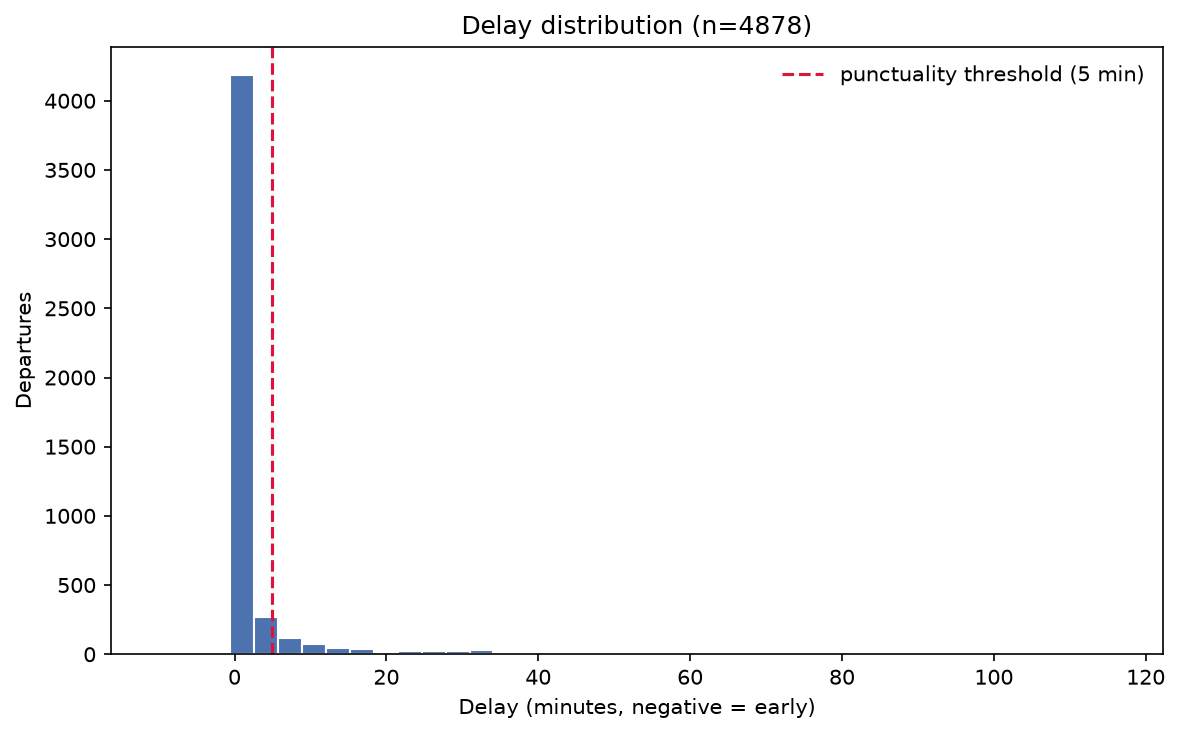

saved    plots/delay_heatmap.png


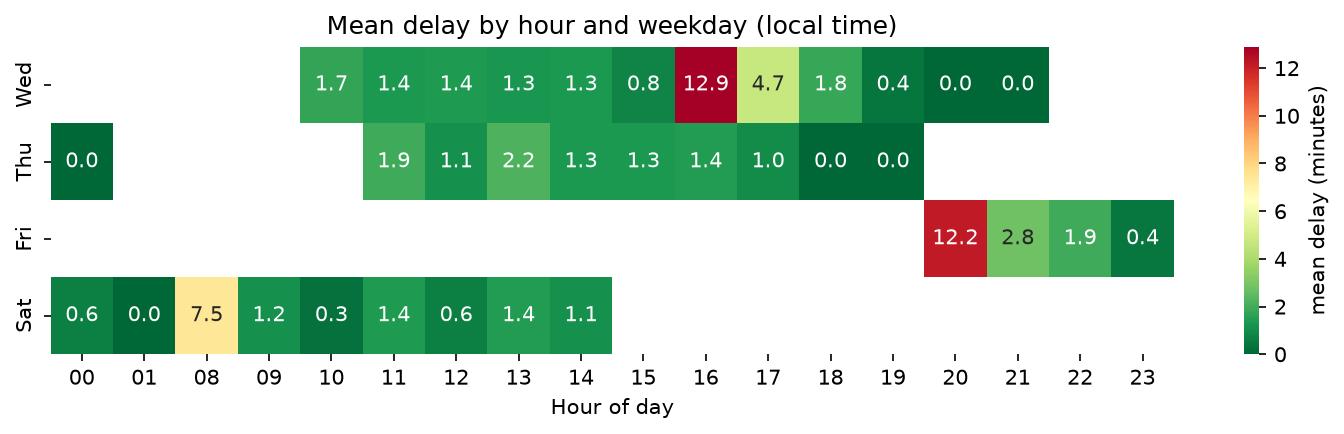

saved    plots/delay_by_line.png


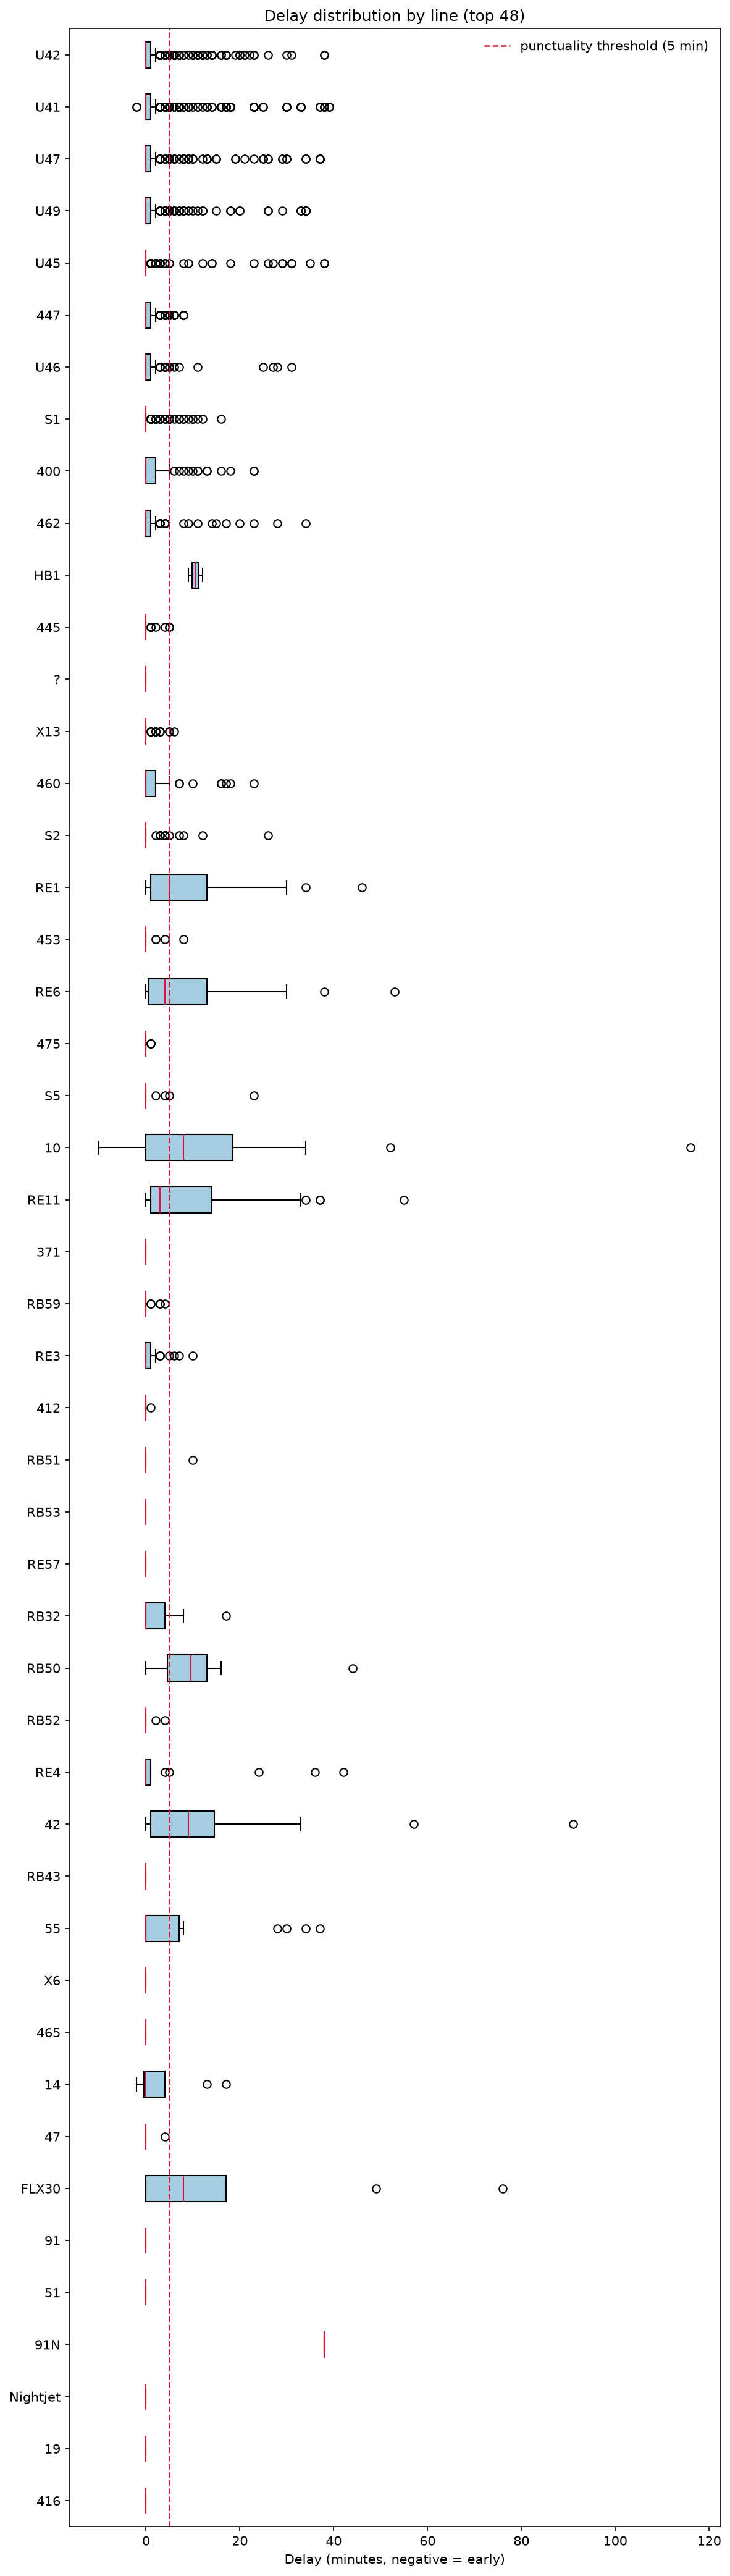

saved    plots/punctuality_trend.png


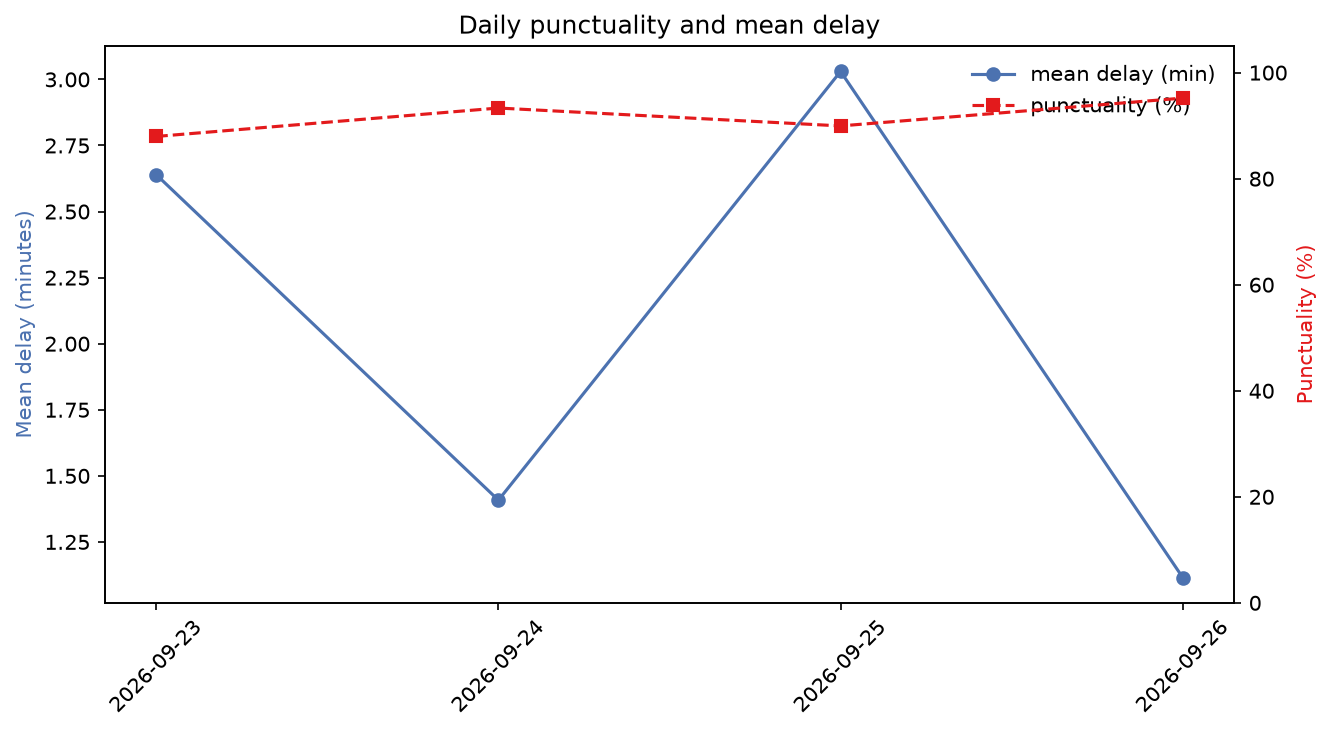

In [5]:
from IPython.display import Image, display

from gleis404 import (
    plot_delay_by_line,
    plot_delay_distribution,
    plot_delay_heatmap,
    plot_punctuality_trend,
)

jobs = {
    "delay_distribution.png": lambda p: plot_delay_distribution(departures, p),
    "delay_heatmap.png": lambda p: plot_delay_heatmap(departures, p),
    "delay_by_line.png": lambda p: plot_delay_by_line(departures, p, top_n=TOP),
    "punctuality_trend.png": lambda p: plot_punctuality_trend(departures, p),
}

for name, render in jobs.items():
    path = render(PLOTS_DIR / name)
    if path is None:
        print(f"skipped  {name}  (not enough data yet — re-run later)")
    else:
        print(f"saved    {path.relative_to(ROOT)}")
        display(Image(filename=str(path), width=600))

## Reproduce everything from the terminal

```bash
uv run -m gleis404 collect --once     # one collection cycle
uv run -m gleis404 stats              # the report above
uv run -m gleis404 plot               # the figures above (plots/*.png)
```

## Data source

Departure data by [Transitous](https://transitous.org/)
([sources](https://transitous.org/sources/)), including
[OpenStreetMap](https://www.openstreetmap.org/copyright) data.
Collection runs every 5 minutes via `uv run -m gleis404 collect`.